# 在 Jupyter Notebook 中读取 BCI2000 数据

这个 Notebook 调用同目录中的 `read_bci2000.py`，读取主采集文件和握力任务文件。

## Goal

读取信号、BCI2000 状态变量和试次信息，并绘制握力曲线。

## Setup

Notebook、读取脚本和两个 `.dat` 文件应放在同一目录。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from read_bci2000 import BCI2000Dat

data_dir = Path.cwd()
main_path = data_dir / "testS001R15.dat"
task_path = data_dir / "testS001R15_1.dat"

assert main_path.exists(), main_path
assert task_path.exists(), task_path

## Steps

### 1. 读取两份数据

`signals` 是内存映射数组，读取大文件时不会一次性复制全部数据到内存。数组形状为 `(采样点, 通道)`。

In [2]:
main_data = BCI2000Dat(main_path)
task_data = BCI2000Dat(task_path)

summary = pd.DataFrame([
    {
        "file": item.path.name,
        "samples": item.samples,
        "channels": item.source_channels,
        "sampling_rate_hz": item.sampling_rate,
        "duration_s": item.samples / item.sampling_rate,
    }
    for item in (main_data, task_data)
])
summary

,file,samples,channels,sampling_rate_hz,duration_s
0,testS001R15.dat,172800,272,2000.0,86.4
1,testS001R15_1.dat,22144,1,256.0,86.5


### 2. 查看通道和状态变量

In [3]:
print("主文件前 20 个通道：", main_data.channel_names[:20])
print("主文件通道总数：", len(main_data.channel_names))
print("任务文件通道：", task_data.channel_names)
print("任务状态变量：", list(task_data.state_definitions))

主文件前 20 个通道： ["T'1", "T'2", "T'3", "T'4", "T'5", "T'6", "T'7", "T'8", "T'9", "T'10", "T'11", "T'12", 'EMPTY', 'EMPTY_14', "A'1", "A'2", "A'3", "A'4", "A'5", "A'6"]
主文件通道总数： 272
任务文件通道： ['GripForce1']
任务状态变量： ['Notes', 'Recording', 'SourceTime', 'FilePart', 'Running', 'TargetCode', 'ResultCode', 'Feedback', 'PauseApplication', 'CursorPosX', 'CursorPosY', 'CursorPosZ', 'GripForceNormalized', 'GripForceRaw', 'TargetAppear', 'FeedbackOnset', 'TrialResult', 'GripMarker', 'SessionTrialIndex', 'BlockIndex', 'BlockTrialIndex', 'BlockPhase', 'SessionComplete', 'PreStimulusTime', 'StimulusTime', 'PresentationRequested', 'PresentationDisplayed', 'PresentationTime', 'PresentationFrame', 'AudioBufferTime', 'AudioPresentationTime', 'VideoStimulusFrame', '__pad0', '__pad1', '__pad2']


### 3. 提取握力信号和任务状态

`state(name)` 按 BCI2000 头文件中的位宽、字节偏移和位偏移解码状态变量。

In [4]:
time_s = np.arange(task_data.samples) / task_data.sampling_rate
grip_force = np.asarray(task_data.signals[:, 0])

task_frame = pd.DataFrame({
    "time_s": time_s,
    "grip_force": grip_force,
    "trial": task_data.state("SessionTrialIndex"),
    "block_phase": task_data.state("BlockPhase"),
    "target_code": task_data.state("TargetCode"),
    "feedback": task_data.state("Feedback"),
    "trial_result": task_data.state("TrialResult"),
    "grip_marker": task_data.state("GripMarker"),
    "normalized_force": task_data.state("GripForceNormalized") / 65535,
})
task_frame.head(10)

,time_s,grip_force,trial,block_phase,target_code,feedback,trial_result,grip_marker,normalized_force
0,0.000000,0.816,0,0,0,0,0,0,0.0
1,0.003906,0.816,0,0,0,0,0,0,0.0
2,0.007812,0.816,0,0,0,0,0,0,0.0
3,0.011719,0.816,0,0,0,0,0,0,0.0
4,0.015625,0.816,0,0,0,0,0,0,0.0
5,0.019531,0.816,0,0,0,0,0,0,0.0
6,0.023438,0.816,0,0,0,0,0,0,0.0
7,0.027344,0.816,0,0,0,0,0,0,0.0
8,0.031250,0.816,0,0,0,0,0,0,0.0
9,0.035156,0.816,0,0,0,0,0,0,0.0


### 4. 汇总每个试次

In [5]:
trial_rows = []
for trial_number, trial_frame in task_frame.query("trial > 0").groupby("trial"):
    feedback_frame = trial_frame.query("feedback > 0")
    trial_rows.append({
        "trial": int(trial_number),
        "start_s": trial_frame.time_s.iloc[0],
        "end_s": trial_frame.time_s.iloc[-1],
        "feedback_start_s": feedback_frame.time_s.iloc[0] if len(feedback_frame) else np.nan,
        "feedback_end_s": feedback_frame.time_s.iloc[-1] if len(feedback_frame) else np.nan,
        "completed": bool(trial_frame.trial_result.max() > 0),
        "max_grip_force": trial_frame.grip_force.max(),
        "max_normalized_force": trial_frame.normalized_force.max(),
    })

trials = pd.DataFrame(trial_rows)
trials

,trial,start_s,end_s,feedback_start_s,feedback_end_s,completed,max_grip_force,max_normalized_force
0,1,2.125,8.496094,3.125,5.496094,True,1.105,1.000000
1,2,8.500,17.746094,9.500,14.746094,True,1.251,1.000000
2,3,17.750,72.371094,18.750,69.371094,True,1.202,1.000000
3,4,72.375,78.496094,73.375,75.496094,True,1.149,1.000000
4,5,78.500,86.496094,79.500,86.496094,False,0.826,0.324987


### 5. 绘制握力和反馈区间

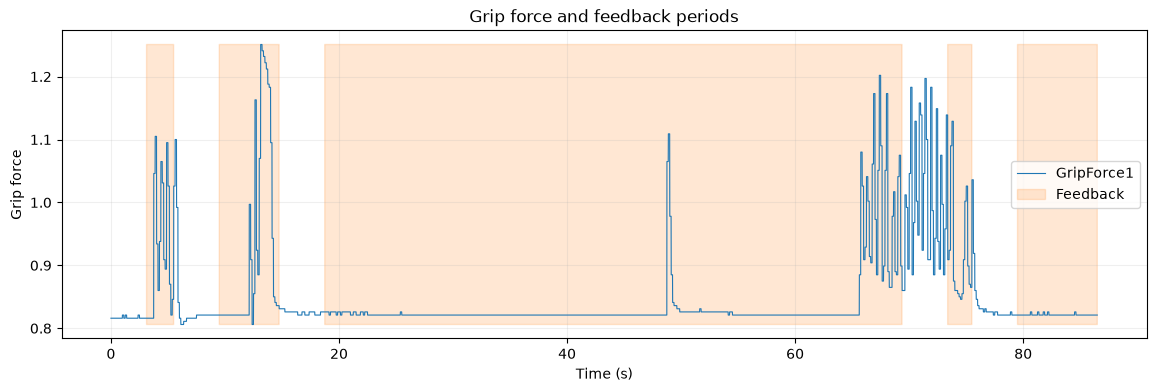

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(task_frame.time_s, task_frame.grip_force, linewidth=0.8, label="GripForce1")
ax.fill_between(
    task_frame.time_s,
    task_frame.grip_force.min(),
    task_frame.grip_force.max(),
    where=task_frame.feedback.astype(bool),
    color="tab:orange",
    alpha=0.18,
    label="Feedback",
)
ax.set(title="Grip force and feedback periods", xlabel="Time (s)", ylabel="Grip force")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## Checks

检查采样点数、时长、试次数以及硬件标记是否存在。

In [7]:
assert main_data.signals.shape == (172800, 272)
assert task_data.signals.shape == (22144, 1)
assert int(task_frame.trial.max()) == 5

print("主文件时长：", main_data.samples / main_data.sampling_rate, "秒")
print("任务文件时长：", task_data.samples / task_data.sampling_rate, "秒")
print("实际开始的试次数：", int(task_frame.trial.max()))
print("GripMarker 非零采样点：", int((task_frame.grip_marker > 0).sum()))

主文件时长： 86.4 秒
任务文件时长： 86.5 秒
实际开始的试次数： 5
GripMarker 非零采样点： 0


## Next Steps

可以继续按 `trial` 切分主采集信号、选择 EEG/EMG 通道，或依据两个文件的时间状态进行精确同步。